### IMPORTING LIBRARIES ###

In [71]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV

### LOADING DATAFRAME ###

In [72]:
business = pd.read_csv(r'D:\BUDT 758C - Predictive analytics\project work\business_data_cleaned.csv')
user = pd.read_csv(r'D:\BUDT 758C - Predictive analytics\project work\user_clean.csv')
tip = pd.read_csv(r'D:\BUDT 758C - Predictive analytics\project work\tips_cleaned.csv')

In [73]:
# Loading train and test datasets:
test_x = pd.read_csv(r'D:\BUDT 758C - Predictive analytics\project work\review_test_x.csv')
train_x = pd.read_csv(r'D:\BUDT 758C - Predictive analytics\project work\review_train_x.csv')
train_y = pd.read_csv(r'D:\BUDT 758C - Predictive analytics\project work\review_train_y.csv')

### UNDERSTANDING THE COLUMNS ###

In [74]:
train_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1577278 entries, 0 to 1577277
Data columns (total 6 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   review_id    1577278 non-null  object 
 1   user_id      1577278 non-null  object 
 2   business_id  1577278 non-null  object 
 3   stars        1577278 non-null  float64
 4   text         1577278 non-null  object 
 5   date         1577278 non-null  object 
dtypes: float64(1), object(5)
memory usage: 72.2+ MB


In [75]:
train_y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1577278 entries, 0 to 1577277
Data columns (total 1 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   top_useful  1577278 non-null  int64
dtypes: int64(1)
memory usage: 12.0 MB


In [76]:
test_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   review_id    700000 non-null  object 
 1   user_id      700000 non-null  object 
 2   business_id  700000 non-null  object 
 3   stars        700000 non-null  float64
 4   text         700000 non-null  object 
 5   date         700000 non-null  object 
dtypes: float64(1), object(5)
memory usage: 32.0+ MB


In [77]:
user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 992656 entries, 0 to 992655
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   user_id          992656 non-null  object 
 1   review_count     992656 non-null  int64  
 2   yelping_since    992656 non-null  object 
 3   useful           992656 non-null  int64  
 4   elite            71540 non-null   object 
 5   friends          609371 non-null  object 
 6   fans             992656 non-null  int64  
 7   average_stars    992656 non-null  float64
 8   elite_na_flag    992656 non-null  int64  
 9   friends_na_flag  992656 non-null  int64  
 10  is_elite         992656 non-null  int64  
 11  elite_years      992656 non-null  int64  
 12  friends_count    992656 non-null  int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 98.5+ MB


In [78]:
tip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300845 entries, 0 to 300844
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   user_id               300845 non-null  object
 1   business_id           300845 non-null  object
 2   text                  300841 non-null  object
 3   date                  300845 non-null  object
 4   compliment_count      300845 non-null  int64 
 5   text_is_null_tips     300845 non-null  bool  
 6   duplicated_rows_tips  300845 non-null  bool  
dtypes: bool(2), int64(1), object(4)
memory usage: 12.1+ MB


### RENAMING CERTAIN COLUMNS ###

In [79]:
user = user.rename(columns={
    "review_count": "user_review_count",
    "fans": "user_fans",
    "average_stars": "user_avg_stars",
    "friends_count": "user_friends_count",
    "is_elite": "user_is_elite",
    "elite_years": "user_elite_years"
})

In [80]:
business = business.rename(columns={
    "review_count": "business_review_count",
    "stars": "business_stars",
    "is_open": "business_is_open"
})

In [81]:
tip = tip.rename(columns={
    "compliment_count": "tip_compliment",
    "text": "tip_text",
    "date": "tip_date"
})

### BUSINESS FEATURE ENGINEERING ###

In [82]:
null_columns = ['BusinessAcceptsCreditCards','BikeParking','ByAppointmentOnly','RestaurantsReservations','HasTV','Caters',
'RestaurantsTakeOut',
'HappyHour',
'OutdoorSeating',
'RestaurantsDelivery',
'BusinessAcceptsBitcoin',
'WheelchairAccessible',
'DogsAllowed',
'Corkage',
'DriveThru',
'CoatCheck',
'BYOB',
'BusinessParking',
'GoodForMeal','Ambience','Music','HairSpecializesIn','BestNights','RestaurantsAttire','Alcohol','AgesAllowed','BYOBCorkage','Smoking','WiFi','NoiseLevel']

In [83]:
business[null_columns] = business[null_columns].fillna(False)

C:\Users\ajays\AppData\Local\Temp\ipykernel_12760\3891109180.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  business[null_columns] = business[null_columns].fillna(False)


In [84]:
business[null_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   BusinessAcceptsCreditCards  15000 non-null  bool  
 1   BikeParking                 15000 non-null  bool  
 2   ByAppointmentOnly           15000 non-null  bool  
 3   RestaurantsReservations     15000 non-null  bool  
 4   HasTV                       15000 non-null  bool  
 5   Caters                      15000 non-null  bool  
 6   RestaurantsTakeOut          15000 non-null  bool  
 7   HappyHour                   15000 non-null  bool  
 8   OutdoorSeating              15000 non-null  bool  
 9   RestaurantsDelivery         15000 non-null  bool  
 10  BusinessAcceptsBitcoin      15000 non-null  bool  
 11  WheelchairAccessible        15000 non-null  bool  
 12  DogsAllowed                 15000 non-null  bool  
 13  Corkage                     15000 non-null  bo

In [85]:
business['RestaurantsAttire'] = business['RestaurantsAttire'].replace(False, 'Unknown')

In [86]:
business['Alcohol'] = business['Alcohol'].replace(False, 'Unknown')

In [87]:
business['AgesAllowed'] = business['AgesAllowed'].replace(False, 'Unknown')

In [88]:
business['BYOBCorkage'] = business['BYOBCorkage'].replace(False, 'No')

In [89]:
business['Smoking'] = business['Smoking'].replace(False,'No')

In [90]:
business['WiFi']= business['WiFi'].replace(False, 'No')
business['WiFi'] =business['WiFi'].replace('Paid','paid')

In [91]:
business['NoiseLevel'] = business['NoiseLevel'].replace(False,'Unknown')

In [92]:
print(business.isnull().sum()[business.isnull().sum()>0])

attributes    267
hours         775
dtype: int64


In [93]:
bool_cols = business.select_dtypes(include=['bool']).columns

business[bool_cols] = business[bool_cols].astype('int64')

In [94]:
business.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Columns: 112 entries, business_id to is_hours_missing
dtypes: float64(3), int64(94), object(15)
memory usage: 12.8+ MB


In [95]:
object_cols= business.select_dtypes(include=['object']).columns

In [96]:
category_cols = ['RestaurantsAttire', 'Alcohol', 'NoiseLevel','WiFi', 'Smoking', 'BYOBCorkage', 'AgesAllowed']


business[category_cols] = business[category_cols].astype('category')

In [97]:
business.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Columns: 112 entries, business_id to is_hours_missing
dtypes: category(7), float64(3), int64(94), object(8)
memory usage: 12.1+ MB


### USER FEATURE ENGINEERING ###

In [98]:
user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 992656 entries, 0 to 992655
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   user_id             992656 non-null  object 
 1   user_review_count   992656 non-null  int64  
 2   yelping_since       992656 non-null  object 
 3   useful              992656 non-null  int64  
 4   elite               71540 non-null   object 
 5   friends             609371 non-null  object 
 6   user_fans           992656 non-null  int64  
 7   user_avg_stars      992656 non-null  float64
 8   elite_na_flag       992656 non-null  int64  
 9   friends_na_flag     992656 non-null  int64  
 10  user_is_elite       992656 non-null  int64  
 11  user_elite_years    992656 non-null  int64  
 12  user_friends_count  992656 non-null  int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 98.5+ MB


In [99]:
user.isna().sum()

user_id                    0
user_review_count          0
yelping_since              0
useful                     0
elite                 921116
friends               383285
user_fans                  0
user_avg_stars             0
elite_na_flag              0
friends_na_flag            0
user_is_elite              0
user_elite_years           0
user_friends_count         0
dtype: int64

In [100]:
user['elite'].value_counts()

elite
2019,20,20,2021                                                      6195
2018,2019,20,20,2021                                                 5335
2021                                                                 4037
2017,2018,2019,20,20,2021                                            4003
20,20,2021                                                           3782
                                                                     ... 
2007,2008,2009,2010,2011,2012,2013,2014,2015,2021                       1
2012,2013,2014,2017,2019,20,20,2021                                     1
2006,2007,2008,2009,2010,2011,2012,2016,2017,2018,2019,20,20,2021       1
2008,2009,2010,2011,2012,2013,20,20,2021                                1
2018.0                                                                  1
Name: count, Length: 1240, dtype: int64

In [101]:
user['elite_year_count'] = user['elite'].apply(lambda x: len(str(x).split(',')) if str(x).strip() not in ('', 'nan', 'None', 'NaT') else 0)

In [102]:
user['elite_year_count'].value_counts()

elite_year_count
0     921116
3      11222
2      11066
4      10773
1      10606
5       8422
6       6012
7       4172
8       3183
9       1665
11      1305
10      1211
12       716
13       578
14       342
15       149
16        78
17        40
Name: count, dtype: int64

In [103]:
bins = [0, 1, 3, 6, 10, float('inf')]
labels = ['0', '1-2', '3-5', '6-9', '10+']

user['elite_year_bin'] = pd.cut(user['elite_year_count'], bins=bins, labels=labels, right=False)

In [104]:
user['elite_year_bin'].value_counts()

elite_year_bin
0      921116
3-5     30417
1-2     21672
6-9     15032
10+      4419
Name: count, dtype: int64

In [105]:
user['yelping_since'] = pd.to_datetime(user['yelping_since']).dt.date

### Tip Feature Engineering ###

In [106]:
tip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300845 entries, 0 to 300844
Data columns (total 7 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   user_id               300845 non-null  object
 1   business_id           300845 non-null  object
 2   tip_text              300841 non-null  object
 3   tip_date              300845 non-null  object
 4   tip_compliment        300845 non-null  int64 
 5   text_is_null_tips     300845 non-null  bool  
 6   duplicated_rows_tips  300845 non-null  bool  
dtypes: bool(2), int64(1), object(4)
memory usage: 12.1+ MB


In [107]:
tip['tip_text'].str.len().describe()

count    300841.000000
mean         61.647674
std          56.287230
min           1.000000
25%          28.000000
50%          49.000000
75%          75.000000
max         500.000000
Name: tip_text, dtype: float64

In [108]:
bins = [0, 25, 50, 100, 200, 500]
labels = ['very_short', 'short', 'medium', 'long', 'very_long']

tip['text_len_bin'] = pd.cut(tip['tip_text'].str.len(), bins=bins, labels=labels,include_lowest=True)

tip['text_len_bin'] = tip['text_len_bin'].cat.add_categories('unknown').fillna('unknown')

In [109]:
tip['text_len_bin'].value_counts()

text_len_bin
medium        107761
short          90986
very_short     64027
long           29219
very_long       8848
unknown            4
Name: count, dtype: int64

In [110]:
tip['tip_date'] = pd.to_datetime(tip['tip_date']).dt.date

In [111]:
tip.head()

,user_id,business_id,tip_text,tip_date,tip_compliment,text_is_null_tips,duplicated_rows_tips,text_len_bin
0,f4adc5a4b15f44b8,0ea9e20365e0a77d,Avengers time with the ladies.,2012-05-18,0,False,False,short
1,7ec0d88337e11197,03f29263c79c1d35,Very decent fried chicken,2017-06-27,0,False,False,very_short
2,ab6e0ec6db8f51f2,06af8df181c39b11,"Saturday, Dec 7th 2013, ride Patco's Silver Sl...",2013-12-03,0,False,False,very_long
3,5b7737f4e936bddb,ea51174b4c8653ae,Tacos,2012-07-27,0,False,False,very_short
4,07da49cf387ba203,6f20385a06ad3b31,Starbucks substitute in boring downtown Tampa....,2012-06-09,0,False,False,medium


In [112]:
tip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300845 entries, 0 to 300844
Data columns (total 8 columns):
 #   Column                Non-Null Count   Dtype   
---  ------                --------------   -----   
 0   user_id               300845 non-null  object  
 1   business_id           300845 non-null  object  
 2   tip_text              300841 non-null  object  
 3   tip_date              300845 non-null  object  
 4   tip_compliment        300845 non-null  int64   
 5   text_is_null_tips     300845 non-null  bool    
 6   duplicated_rows_tips  300845 non-null  bool    
 7   text_len_bin          300845 non-null  category
dtypes: bool(2), category(1), int64(1), object(4)
memory usage: 12.3+ MB


### MERGING THE DATAFRAMES ###

In [113]:
train = train_x.copy()

In [114]:
train = train.merge(user, on="user_id", how="left")
test_x = test_x.merge(user, on="user_id", how="left")

train = train.merge(business, on="business_id", how="left")
test_x = test_x.merge(business, on="business_id", how="left")

In [115]:
tip_biz = tip.groupby('business_id').agg(
    tip_count           = ('tip_text', 'count'),      
    tip_avg_compliments = ('tip_compliment', 'mean')
).reset_index()

print(f"tip_biz shape: {tip_biz.shape}")  # should be <= 300,845 unique businesses
print(tip_biz.head())

tip_biz shape: (14686, 3)
        business_id  tip_count  tip_avg_compliments
0  0000a2efa84a6d8e          8             0.000000
1  0001eb825604ba80         10             0.000000
2  0003118d1ad3ffcd         24             0.083333
3  0005dc2447718e1b          1             0.000000
4  000cee8e368586cf         12             0.000000


In [116]:
train = train.merge(tip_biz, on='business_id', how='left')
test_x  = test_x.merge(tip_biz,  on='business_id', how='left')

# Fill NaNs (businesses with no tips)
train[['tip_count', 'tip_avg_compliments']] = train[['tip_count', 'tip_avg_compliments']].fillna(0)
test_x[['tip_count', 'tip_avg_compliments']]  = test_x[['tip_count', 'tip_avg_compliments']].fillna(0)

# Verify
print(train[['tip_count', 'tip_avg_compliments']].isna().sum())
print(test_x[['tip_count', 'tip_avg_compliments']].isna().sum())

tip_count              0
tip_avg_compliments    0
dtype: int64
tip_count              0
tip_avg_compliments    0
dtype: int64


### TRAIN MODIFICATION ###

In [117]:
train.head()

,review_id,user_id,business_id,stars,text,date,user_review_count,yelping_since,useful,elite,...,Travel,Shopping,HealthandFitness,Automotive,Pets,Activelife,Other,is_hours_missing,tip_count,tip_avg_compliments
0,a021fc6e6f9f0a89,cc59fcfd2eef6f33,3246f2e18cd91125,10.00,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,16.0,2014-01-17,1.0,NaN,...,0,0,0,0,0,0,0,1,29.0,0.000000
1,e2f8f0b977247525,887f36457cda93f3,9b667f612347f52d,1.04,I am a long term frequent customer of this est...,2015-09-23 23:10:31,6.0,2014-06-15,5.0,NaN,...,0,0,0,0,0,0,0,1,28.0,0.035714
2,38306a152b067345,40427c5f2fe0262d,4a305623b48d793d,6.56,Love going here for happy hour or dinner! Gre...,2014-06-27 22:44:01,272.0,2011-05-15,112.0,"2014,2015,2016",...,0,0,0,0,0,0,0,0,63.0,0.000000
3,9401208079837bdf,6a8b86249ddfe6eb,583a05bb24b08856,10.00,My absolute favorite cafe in the city. Their b...,2014-11-12 15:30:27,362.0,2010-02-22,217.0,2018,...,0,0,0,0,0,0,0,0,60.0,0.000000
4,4528c75b77b05a8e,f8a19bf5830cb4a8,e08f9589bffb26f7,10.00,HOLY SMOKES!\n\nactual pumpkin pie mixed in wi...,2009-10-13 19:49:51,604.0,2006-07-13,504.0,"2007,2008,2009,2010,2011",...,0,0,0,0,0,0,0,0,327.0,0.006116


In [118]:
train.describe()

,stars,user_review_count,useful,user_fans,user_avg_stars,elite_na_flag,friends_na_flag,user_is_elite,user_elite_years,user_friends_count,...,Travel,Shopping,HealthandFitness,Automotive,Pets,Activelife,Other,is_hours_missing,tip_count,tip_avg_compliments
count,1.577278e+06,1.577276e+06,1.577276e+06,1.577276e+06,1.577276e+06,1.577276e+06,1.577276e+06,1.577276e+06,1.577276e+06,1.577276e+06,...,1.577278e+06,1.577278e+06,1.577278e+06,1.577278e+06,1.577278e+06,1.577278e+06,1.577278e+06,1.577278e+06,1.577278e+06,1.577278e+06
mean,6.844872e+00,2.496567e+02,4.182850e+02,1.327810e+01,6.228087e+00,7.406497e-01,2.569981e-01,2.593503e-01,1.361329e+00,1.248661e+02,...,5.000260e-02,5.001084e-02,2.009031e-02,2.067359e-02,6.397731e-03,1.945821e-02,6.308336e-04,3.095770e-01,6.473790e+01,1.216266e-02
std,3.360994e+00,7.029308e+02,3.054908e+03,8.735889e+01,2.001334e+00,4.382783e-01,4.369785e-01,4.382783e-01,2.833897e+00,4.079313e+02,...,2.179504e-01,2.179674e-01,1.403093e-01,1.422892e-01,7.972957e-02,1.381289e-01,2.510849e-02,4.623194e-01,1.299377e+02,3.750382e-02
min,1.040000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.040000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.080000e+00,1.400000e+01,4.000000e+00,0.000000e+00,5.068303e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.100000e+01,0.000000e+00
50%,6.560000e+00,5.200000e+01,2.100000e+01,0.000000e+00,6.272760e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.900000e+01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.800000e+01,0.000000e+00
75%,1.000000e+01,2.080000e+02,1.190000e+02,4.000000e+00,7.448144e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.150000e+02,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,6.600000e+01,1.234568e-02
max,1.000000e+01,3.494400e+04,2.062960e+05,1.249700e+04,1.000000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.700000e+01,1.499500e+04,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.571000e+03,3.000000e+00


In [119]:
bins = [0, 100, 250, 500, 1000, float('inf')]
labels = ['very_short', 'short', 'medium', 'long', 'very_long']

train['text_len_bin'] = pd.cut(train['text'].str.len(), bins=bins, labels=labels, include_lowest=True)

In [120]:
train['text_len_bin'].value_counts()

text_len_bin
medium        486462
long          412450
short         407817
very_long     221063
very_short     49486
Name: count, dtype: int64

In [121]:
print(train.isnull().sum()[train.isnull().sum()>0])

user_review_count           2
yelping_since               2
useful                      2
elite                 1168211
friends                405359
user_fans                   2
user_avg_stars              2
elite_na_flag               2
friends_na_flag             2
user_is_elite               2
user_elite_years            2
user_friends_count          2
elite_year_count            2
elite_year_bin              2
attributes              15539
hours                   42774
dtype: int64


In [122]:
train[train['user_review_count'].isna()]

,review_id,user_id,business_id,stars,text,date,user_review_count,yelping_since,useful,elite,...,Shopping,HealthandFitness,Automotive,Pets,Activelife,Other,is_hours_missing,tip_count,tip_avg_compliments,text_len_bin
487324,638aedbdb24b4993,74d700a99bcd4345,2881a10bd250b11f,1.04,Ordered 2 meatball park sandwiches both sandwi...,2022-01-19 17:45:25,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,7.0,0.0,short
491545,fcbde6327aba44c7,e198f170a4d97a7a,d96f06e97ee1aad5,10.00,Awesome to the max \nawesome to the max\naweso...,2022-01-19 18:34:30,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,1,1.0,0.0,very_short


Need to make sure these two rows have all the data replaced with 0 or unknown (cant drop it because it will cause an imbalance between train_x and train_y)

In [123]:
print(train.isnull().sum()[train.isnull().sum()>0])

user_review_count           2
yelping_since               2
useful                      2
elite                 1168211
friends                405359
user_fans                   2
user_avg_stars              2
elite_na_flag               2
friends_na_flag             2
user_is_elite               2
user_elite_years            2
user_friends_count          2
elite_year_count            2
elite_year_bin              2
attributes              15539
hours                   42774
dtype: int64


In [124]:
train = train.drop(columns = ['elite','friends','attributes','hours','categories','useful'], axis=1)

In [125]:
train.isnull().sum()

review_id              0
user_id                0
business_id            0
stars                  0
text                   0
                      ..
Other                  0
is_hours_missing       0
tip_count              0
tip_avg_compliments    0
text_len_bin           0
Length: 128, dtype: int64

In [126]:
train.shape

(1577278, 128)

### TEST MODIFICATION ###

In [127]:
bins = [0, 100, 250, 500, 1000, float('inf')]
labels = ['very_short', 'short', 'medium', 'long', 'very_long']

test_x['text_len_bin'] = pd.cut(test_x['text'].str.len(), bins=bins, labels=labels, include_lowest=True)

test_x['text_len_bin'] = test_x['text_len_bin'].cat.add_categories('unknown').fillna('unknown')

In [128]:
test_x = test_x.drop(columns = ['elite','friends','attributes','hours','useful','categories'], axis=1)

### FINAL CHECK ###

In [129]:
train.head()

,review_id,user_id,business_id,stars,text,date,user_review_count,yelping_since,user_fans,user_avg_stars,...,Shopping,HealthandFitness,Automotive,Pets,Activelife,Other,is_hours_missing,tip_count,tip_avg_compliments,text_len_bin
0,a021fc6e6f9f0a89,cc59fcfd2eef6f33,3246f2e18cd91125,10.00,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,16.0,2014-01-17,0.0,9.148614,...,0,0,0,0,0,0,1,29.0,0.000000,short
1,e2f8f0b977247525,887f36457cda93f3,9b667f612347f52d,1.04,I am a long term frequent customer of this est...,2015-09-23 23:10:31,6.0,2014-06-15,0.0,2.320000,...,0,0,0,0,0,0,1,28.0,0.035714,medium
2,38306a152b067345,40427c5f2fe0262d,4a305623b48d793d,6.56,Love going here for happy hour or dinner! Gre...,2014-06-27 22:44:01,272.0,2011-05-15,9.0,6.501792,...,0,0,0,0,0,0,0,63.0,0.000000,short
3,9401208079837bdf,6a8b86249ddfe6eb,583a05bb24b08856,10.00,My absolute favorite cafe in the city. Their b...,2014-11-12 15:30:27,362.0,2010-02-22,6.0,4.996073,...,0,0,0,0,0,0,0,60.0,0.000000,medium
4,4528c75b77b05a8e,f8a19bf5830cb4a8,e08f9589bffb26f7,10.00,HOLY SMOKES!\n\nactual pumpkin pie mixed in wi...,2009-10-13 19:49:51,604.0,2006-07-13,12.0,6.132665,...,0,0,0,0,0,0,0,327.0,0.006116,short


In [130]:
test_x.head()

,review_id,user_id,business_id,stars,text,date,user_review_count,yelping_since,user_fans,user_avg_stars,...,Shopping,HealthandFitness,Automotive,Pets,Activelife,Other,is_hours_missing,tip_count,tip_avg_compliments,text_len_bin
0,f8b148b379210e1a,719aa90524cdf560,413f16f57ef78a8d,10.00,"Perfecte gerechten, prima bediening.\nDe sfeer...",2017-08-11 03:32:24,20.0,2017-08-02,0.0,7.320625,...,0,0,0,0,0,0,0,49.0,0.020408,medium
1,3280f881128f06c6,b3da5d1bde948a24,cf9d61e5d79653d4,10.00,Besides the crowds its the best place to get a...,2013-07-02 22:38:39,574.0,2008-09-27,6.0,6.766766,...,1,1,0,0,0,0,0,827.0,0.007255,medium
2,1678c8bee69fd046,4669ff016e8e4adb,b61a7cd0c7638bc9,4.08,When we first started ordering from here the f...,2015-03-22 03:27:04,70.0,2015-03-21,1.0,6.560000,...,0,0,0,0,0,0,0,15.0,0.000000,medium
3,41362acc77a0b7a1,3c85751f597edfc7,e751e329d26ba39c,10.00,My girlfriend surprised me for my 30th birthda...,2019-03-04 14:53:08,20.0,2016-04-15,0.0,7.874036,...,0,0,0,0,1,0,0,3.0,0.000000,medium
4,18d100b80a2c9998,369fc1189623b884,a9c02dd82b7c9a05,6.56,"We were seated in the outside courtyard, very ...",2014-08-16 17:05:03,680.0,2010-03-13,35.0,5.595085,...,0,0,0,0,0,0,0,68.0,0.014706,very_long


### Adding Time dimensionality to the Random Forest ###


date feature engineering

In [131]:

train['date'] = pd.to_datetime(train['date'])
test_x['date'] = pd.to_datetime(test_x['date'])

reference_date = pd.Timestamp('2022-12-31')

train['days_since_review'] = (reference_date - train['date']).dt.days
test_x['days_since_review'] = (reference_date - test_x['date']).dt.days

# Year and month
train['review_year'] = train['date'].dt.year
train['review_month'] = train['date'].dt.month

test_x['review_year'] = test_x['date'].dt.year
test_x['review_month'] = test_x['date'].dt.month

In [132]:
train['days_since_review'].value_counts()

days_since_review
1412    891
1636    875
1755    847
1377    840
1622    835
       ... 
5991      1
6135      1
5942      1
6010      1
5801      1
Name: count, Length: 5873, dtype: int64

In [133]:
train['review_month'].value_counts()

review_month
7     148388
8     142861
1     136685
3     136534
6     135246
5     132663
10    127682
9     126871
4     124854
2     124276
12    121926
11    119292
Name: count, dtype: int64

In [134]:
train['review_year'].value_counts()

review_year
2018    206191
2019    204032
2017    187398
2016    174665
2015    160076
2021    129361
2014    120658
2020    117946
2013     87094
2012     64906
2011     53244
2010     32300
2009     17474
2008     10788
2022      6295
2007      3689
2006       958
2005       203
Name: count, dtype: int64

 YELPING SINCE FEATURE ENGINEERING 

In [135]:
# Convert to datetime
train['yelping_since'] = pd.to_datetime(train['yelping_since'])
test_x['yelping_since'] = pd.to_datetime(test_x['yelping_since'])

reference_date = pd.Timestamp('2022-12-31')  # or use train['date'].max()

# How long the user has been on Yelp (in days)
train['user_tenure_days'] = (reference_date - train['yelping_since']).dt.days
test_x['user_tenure_days'] = (reference_date - test_x['yelping_since']).dt.days

# Year they joined — captures Yelp's early adopter vs late joiner dynamic
train['yelping_since_year'] = train['yelping_since'].dt.year
test_x['yelping_since_year'] = test_x['yelping_since'].dt.year

# Drop the raw column
train = train.drop(columns=['yelping_since'])
test_x = test_x.drop(columns=['yelping_since'])

In [136]:
train['user_tenure_days'].value_counts()

user_tenure_days
3157.0    988
4174.0    979
4331.0    953
4067.0    922
3164.0    917
         ... 
6249.0      1
6650.0      1
6459.0      1
6620.0      1
6576.0      1
Name: count, Length: 6127, dtype: int64

### Random Forest ###

In [137]:
# set plotting defaults
plt.rc('axes', titlesize=22, labelsize=22)  # Title and axis labels
plt.rc('xtick', labelsize=20)  # X-axis tick labels
plt.rc('ytick', labelsize=20)  # Y-axis tick labels
plt.rc('legend', fontsize=20, title_fontsize=20)  # Legend

In [138]:
drop_cols = ['review_id','user_id','business_id','text', 'address',
             'city','state','postal_code','latitude','longitude','date']

y = train_y
train.drop(columns=drop_cols, inplace=True)

X_train, X_val, y_train, y_val = train_test_split(train, y, test_size=0.2, random_state=42,stratify=y)


print(f"X_train: {X_train.shape}")   # ~880k rows
print(f"X_val:   {X_val.shape}")     # ~220k rows
print(f"y_train class balance:\n{y_train.value_counts(normalize=True)}")
print(f"y_val class balance:\n{y_val.value_counts(normalize=True)}")


X_train: (1261822, 121)
X_val:   (315456, 121)
y_train class balance:
top_useful
0             0.878812
1             0.121188
Name: proportion, dtype: float64
y_val class balance:
top_useful
0             0.878814
1             0.121186
Name: proportion, dtype: float64


In [139]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical cols to encode:", cat_cols)

enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

train_encoded = enc.fit_transform(X_train[cat_cols])
val_encoded = enc.transform(X_val[cat_cols])

encoded_cols = enc.get_feature_names_out(cat_cols)
train_encoded_df = pd.DataFrame(train_encoded, columns=encoded_cols, index=X_train.index)
val_encoded_df = pd.DataFrame(val_encoded, columns=encoded_cols, index=X_val.index)

X_train = X_train.drop(columns=cat_cols).join(train_encoded_df)
X_val = X_val.drop(columns=cat_cols).join(val_encoded_df)

Categorical cols to encode: ['elite_year_bin', 'RestaurantsAttire', 'Alcohol', 'NoiseLevel', 'WiFi', 'Smoking', 'BYOBCorkage', 'AgesAllowed', 'text_len_bin']


In [140]:
rf_base = RandomForestClassifier(
    class_weight='balanced',  # you know your target is imbalanced, keep this fixed
    oob_score=False,          # must be False — CV does its own validation
    n_jobs=-1,                # always use all cores
    random_state=42           # reproducibility, always fixed
)

In [ ]:
import sklearn
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': [10, 15, 20, 25],
    'min_samples_leaf': randint(20, 100),
    'min_samples_split': randint(50, 200),
    'max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=rf_base, param_distributions=param_dist, n_iter=30, cv=5, scoring='roc_auc', n_jobs=4, random_state=42, verbose=2, refit = True)

random_search.fit(X_train.sample(frac=0.2), y_train.sample(frac=0.2))

print("Best params:", random_search.best_params_)
print("Best CV AUC:", random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


In [ ]:
from sklearn.utils import resample

X_sample, y_sample = resample(X_train, y_train, n_samples=50_000, random_state=42, stratify=y_train)
random_search.fit(X_sample, y_sample)   # fast search on subset

# Then refit best params on full data
final_rf = RandomForestClassifier(**random_search.best_params_, n_jobs=-1, random_state=42)
final_rf.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report


# Predictions
y_pred = final_rf.predict(X_val)

# Simple accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

# Detailed breakdown (precision, recall, F1 per class)
print(classification_report(y_val, y_pred))

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    1.2s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    7.3s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:   12.1s finished


Test Accuracy: 0.7830
              precision    recall  f1-score   support

           0       0.96      0.79      0.86    970292
           1       0.33      0.74      0.45    133803

    accuracy                           0.78   1104095
   macro avg       0.64      0.76      0.66   1104095
weighted avg       0.88      0.78      0.81   1104095



In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    1.1s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    6.4s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:   11.3s finished


Validation AUC: 0.8485

Optimal Threshold : 0.6402
TPR at threshold  : 0.5449
FPR at threshold  : 0.0950


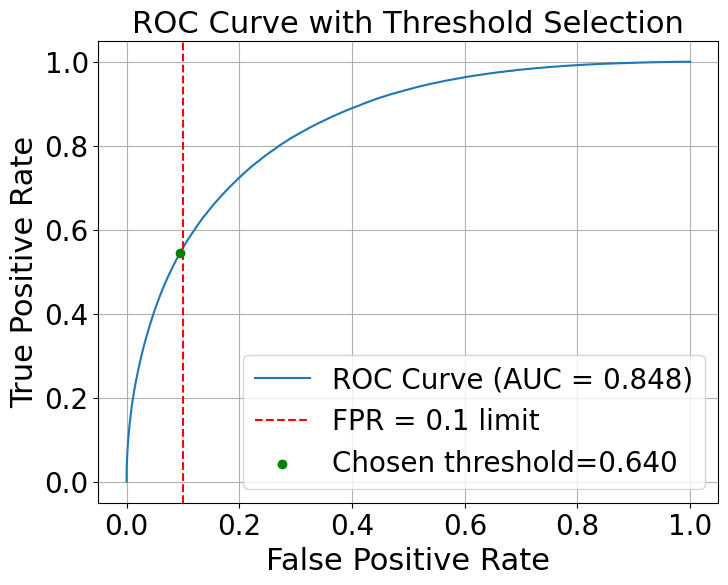

In [ ]:
# Get predicted probabilities on validation set

best_rf = grid_search.best_estimator_

# Drop-in replacement for your existing rf variable
y_val_proba = best_rf.predict_proba(X_val)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
auc = roc_auc_score(y_val, y_val_proba)
print(f"Validation AUC: {auc:.4f}")

# --- Find optimal threshold: max TPR where FPR < 0.1 ---
valid_mask = fpr < 0.095
if valid_mask.any():
    best_idx = np.argmax(tpr[valid_mask])           # Highest TPR in FPR < 0.1 zone
    best_threshold = thresholds[valid_mask][best_idx]
    best_tpr = tpr[valid_mask][best_idx]
    best_fpr = fpr[valid_mask][best_idx]
else:
    print("Warning: No threshold achieves FPR < 0.1. Relax constraint or retrain.")

print(f"\nOptimal Threshold : {best_threshold:.4f}")
print(f"TPR at threshold  : {best_tpr:.4f}")
print(f"FPR at threshold  : {best_fpr:.4f}")

# Plot ROC curve with selected threshold
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.3f})')
plt.axvline(x=0.1, color='red', linestyle='--', label='FPR = 0.1 limit')
plt.scatter([best_fpr], [best_tpr], color='green', zorder=5,
            label=f'Chosen threshold={best_threshold:.3f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Threshold Selection')
plt.legend()
plt.grid(True)
plt.show()

### Evaluation on Validation set ####

In [ ]:
# Apply chosen threshold
y_val_pred = (y_val_proba >= best_threshold).astype(int)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()
tpr_final = tp / (tp + fn)
fpr_final = fp / (fp + tn)
acc_final = accuracy_score(y_val, y_val_pred)

print(f"\n=== Validation Metrics (threshold={best_threshold:.4f}) ===")
print(f"Accuracy  : {acc_final:.4f}")
print(f"TPR (Recall): {tpr_final:.4f}")
print(f"FPR        : {fpr_final:.4f}   ← Must be < 0.1")
print(f"\nClassification Report:\n")
print(classification_report(y_val, y_val_pred))


=== Validation Metrics (threshold=0.6402) ===
Accuracy  : 0.8614
TPR (Recall): 0.5449
FPR        : 0.0950   ← Must be < 0.1

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.91      0.92    970292
           1       0.44      0.54      0.49    133803

    accuracy                           0.86   1104095
   macro avg       0.69      0.72      0.70   1104095
weighted avg       0.88      0.86      0.87   1104095



### Prediction on test_x ###

In [ ]:
test_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Columns: 132 entries, review_id to yelping_since_year
dtypes: category(9), datetime64[ns](1), float64(17), int32(2), int64(95), object(8)
memory usage: 657.6+ MB


In [ ]:
drop_cols = ['review_id','user_id','business_id','text','date', 'address',
             'city','state','postal_code','latitude','longitude']

test_x.drop(columns=drop_cols, inplace=True)

In [ ]:
cat_cols = test_x.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical cols to encode:", cat_cols)

test_encoded = enc.transform(test_x[cat_cols])
encoded_cols = enc.get_feature_names_out(cat_cols)
test_encoded_df = pd.DataFrame(test_encoded, columns=encoded_cols, index=test_x.index)

test_x = test_x.drop(columns=cat_cols).join(test_encoded_df)

Categorical cols to encode: ['elite_year_bin', 'RestaurantsAttire', 'Alcohol', 'NoiseLevel', 'WiFi', 'Smoking', 'BYOBCorkage', 'AgesAllowed', 'text_len_bin']


In [ ]:
# Predict probabilities
test_proba = rf.predict_proba(test_x)[:, 1]

# Apply the same optimal threshold
test_pred = (test_proba >= best_threshold).astype(int)

# Save results
output = pd.DataFrame({
    'predicted_top_useful': test_pred,
    'probability':          test_proba
})
output.to_csv('test_predictions.csv', index=False)
print(output['predicted_top_useful'].value_counts())
print("\nPredictions saved to test_predictions.csv")

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.7s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    4.2s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    7.1s finished


predicted_top_useful
0    595133
1    104867
Name: count, dtype: int64

Predictions saved to test_predictions.csv


### Feature Selection ###

In [ ]:
# Check which features matter most
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(20)

user_fans                0.124613
text_len_bin             0.088943
stars                    0.074477
user_elite_years         0.054542
user_friends_count       0.050338
elite_na_flag            0.048156
elite_year_bin           0.048059
user_is_elite            0.045553
user_review_count        0.045150
days_since_review        0.044323
elite_year_count         0.041779
user_tenure_days         0.036156
review_year              0.028546
user_avg_stars           0.024607
tip_count                0.024459
yelping_since_year       0.023768
business_review_count    0.021635
FoodorRestaurant         0.013227
NoiseLevel               0.012262
business_stars           0.012047
dtype: float64